# Необходимо реализовать мехинизм вычисления метки подынтервалу (подокну) (при перекрытии окон при разбиении) на основе ответов модели
 1) Суммарное агрегирование для подынтервала
 2) Среднее арифметическое вероятности в зависимости от дистанции (от центра окна). Так как свёрточная сеть лучше работает на серидине окна (проблемы с краями) 

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().absolute().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.time_series import load_multi_csv, load_angles
from src.sliding_window import sliding_windows_multiplet
from src.inference import load_model, predict_multiplet, predict_classes_from_proba
from src.visual import plot_raw_multiplet, plot_multiplet_predictions, plot_angles
from src.criteria import process_multiplet

2026-05-05 16:34:49.679481: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
data_path=str(PROJECT_ROOT)+'/time_series/TOI-1136_arg_p_max_history_resonance_3_2_between_1_and_2_original_angles.npz'
data = load_angles(data_path, ['phi_0_original', 'phi_1_original'], time_column='time_years',convert_to_xy=True)

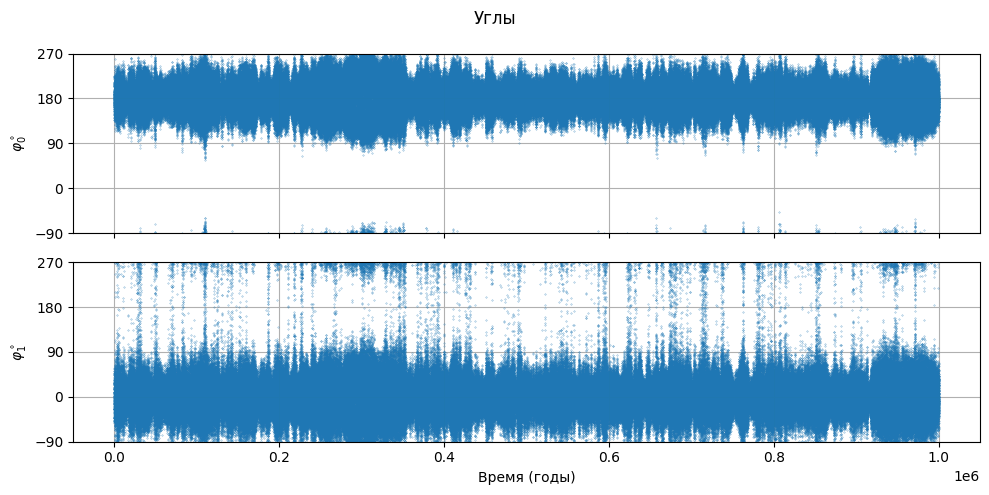

In [6]:
plot_angles(data['time_years'], data['angles_deg'], title='Углы')

In [8]:
windows = sliding_windows_multiplet(
    data_dict=data,
    window_length=4000,
    overlap_ratio=0.5
)

In [9]:
model = load_model('1', models_dir=str(PROJECT_ROOT)+'/models/')
probs = predict_multiplet(windows['angle_windows'], model)
classes = [predict_classes_from_proba(p) for p in probs]

W0000 00:00:1777981121.096542  140170 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


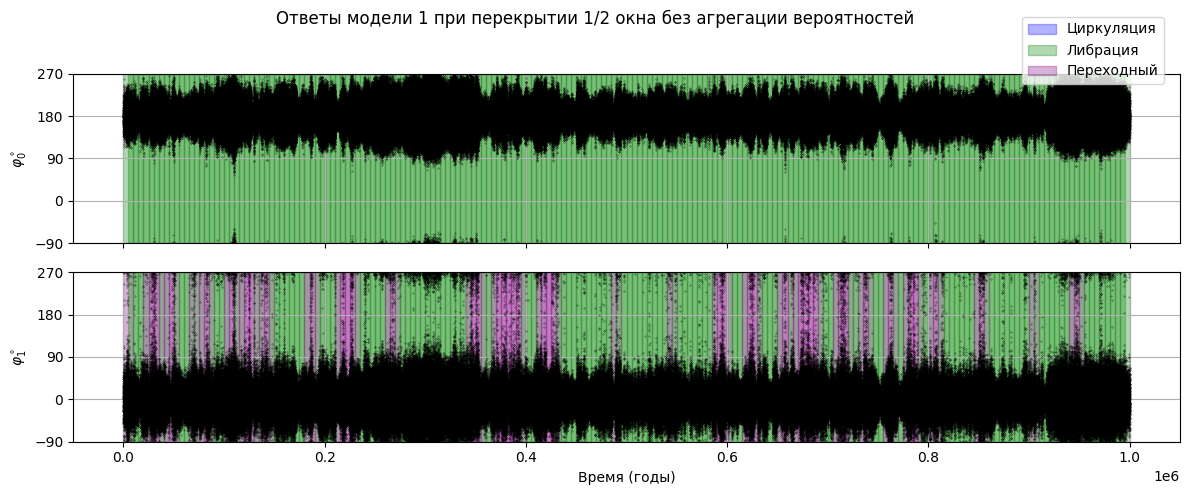

In [10]:
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes,
    title='Ответы модели 1 при перекрытии 1/2 окна без агрегации вероятностей',
    angle_min=-90., #Диапазоны нормализации угла
    angle_max=270.
    # save_path='/content/drive/MyDrive/Diplom_data/resonance_sorter/notebook/predict_TOI1136_model1.png'

)

На самый первый подынтервал $1$ и последний $N$ приходится по одному прогнозу от модели. На все остальные по 2. То есть:
\begin{equation}
\begin{split}
& F_{p_n} \in [f_N,f_{N+1}], F_{p_n} \ne F_{p_1} \lor F_{p_N}, \\
& F_{p_1} \in [f_1], \\
& F_{p_N} \in [f_N], \\
\end{split}
\end{equation}

где $F_{p_n}$ $-$ подынтервал, $f_N$ $-$ окно разбиения. При перекрытии окон разбиения в $1/2$ окна, получается $2n-1$ окон, если исходный ряд разбивался на $n$ окон (без перекрытий). Подынтервалов, соответственно $2n$, из которых $2$, получат по одному прогнозу, а $2(n-1)$ $-$ по $2$ прогноза.